# Step 4: Baseline Models & Failure Analysis

---
## Section 1: Experimental Setup


### 1.1 Metrics
- **MSE** (Mean Squared Error) — per maturity + aggregate
- **RMSE** — root MSE for interpretability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent / 'Benchmarks'))
from random_walk import run_baseline as rw_baseline, TARGETS
from linear_regression import run_baseline as lr_baseline

plt.style.use('seaborn-v0_8-whitegrid')
DATA_PATH = Path.cwd().parent / 'Data' / 'Processed'
RESULTS_PATH = Path.cwd().parent / 'Experiments' / 'Results'

In [2]:
# Load data
features = pd.read_csv(DATA_PATH / 'normalized_features.csv', parse_dates=['date'])
targets = pd.read_csv(DATA_PATH / 'maturity_targets.csv', parse_dates=['date'])

n = len(targets)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

print(f"Total observations: {n}")
print(f"Train: {targets['date'].iloc[0].strftime('%Y-%m')} to {targets['date'].iloc[train_end-1].strftime('%Y-%m')} ({train_end} obs)")
print(f"Val:   {targets['date'].iloc[train_end].strftime('%Y-%m')} to {targets['date'].iloc[val_end-1].strftime('%Y-%m')} ({val_end - train_end} obs)")
print(f"Test:  {targets['date'].iloc[val_end].strftime('%Y-%m')} to {targets['date'].iloc[-1].strftime('%Y-%m')} ({n - val_end} obs)")

Total observations: 117
Train: 2016-02 to 2022-10 (81 obs)
Val:   2022-11 to 2024-04 (18 obs)
Test:  2024-05 to 2025-11 (18 obs)


---
## Section 2: Random Walk Results

**Model:** $\hat{y}_t = y_{t-1}$ (one-step-ahead, no learning)

In [3]:
# Run random walk baseline
rw_results, _ = rw_baseline(test_ratio=0.15)

Data: 117 obs | Test starts: idx 99 (2024-05)

Random Walk Results (Test Set):
maturity      mse     rmse
      y1 0.043489 0.208540
      y2 0.064017 0.253015
      y5 0.062539 0.250078
     y10 0.045994 0.214463
     y20 0.038022 0.194993
     y30 0.035800 0.189209

Aggregate MSE: 0.048310


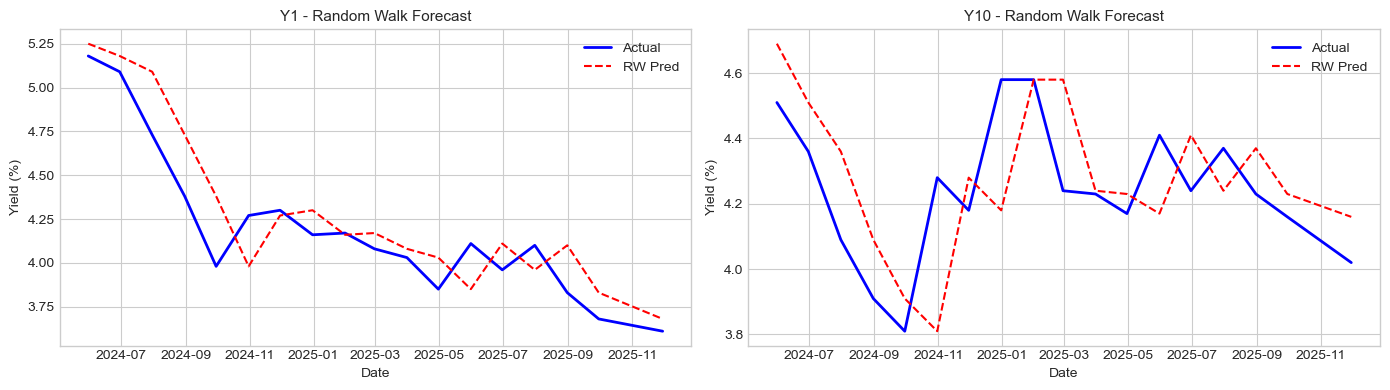

In [4]:
# Visualize: Actual vs Predicted for y10
test_start = int(len(targets) * 0.85)
test_df = targets.iloc[test_start:].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, mat in enumerate(['y1', 'y10']):
    ax = axes[i]
    ax.plot(test_df['date'], test_df[mat], 'b-', label='Actual', linewidth=2)
    ax.plot(test_df['date'], targets[mat].shift(1).iloc[test_start:], 'r--', label='RW Pred', linewidth=1.5)
    ax.set_title(f'{mat.upper()} - Random Walk Forecast', fontsize=11)
    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel('Yield (%)')

plt.tight_layout()
plt.show()

---
## Section 3: Linear Regression Results

**Model:** $y_t = \beta^T S_t + \epsilon$ (separate regression per maturity)

In [5]:
# Run linear regression baseline
lr_results, coefs = lr_baseline()

Split: Train 0-81 | Val 81-99 | Test 99-117
Test period: 2024-05 to 2025-11

Linear Regression Results (Test Set):
maturity      mse     rmse
      y1 2.288850 1.512894
      y2 2.850860 1.688449
      y5 1.360473 1.166393
     y10 0.051895 0.227806
     y20 0.017542 0.132444
     y30 0.377098 0.614083

Aggregate MSE: 1.157786


In [6]:
# MSE Comparison: Random Walk vs Linear Regression
comparison = rw_results[['maturity', 'mse']].rename(columns={'mse': 'RW_MSE'})
comparison = comparison.merge(lr_results[['maturity', 'mse']].rename(columns={'mse': 'LR_MSE'}), on='maturity')
comparison['RW_Wins'] = comparison['RW_MSE'] < comparison['LR_MSE']

print("MSE Comparison (Test Set):")
print(comparison.to_string(index=False))
print(f"\nRandom Walk wins on {comparison['RW_Wins'].sum()}/{len(comparison)} maturities")

MSE Comparison (Test Set):
maturity   RW_MSE   LR_MSE  RW_Wins
      y1 0.043489 2.288850     True
      y2 0.064017 2.850860     True
      y5 0.062539 1.360473     True
     y10 0.045994 0.051895     True
     y20 0.038022 0.017542    False
     y30 0.035800 0.377098     True

Random Walk wins on 5/6 maturities


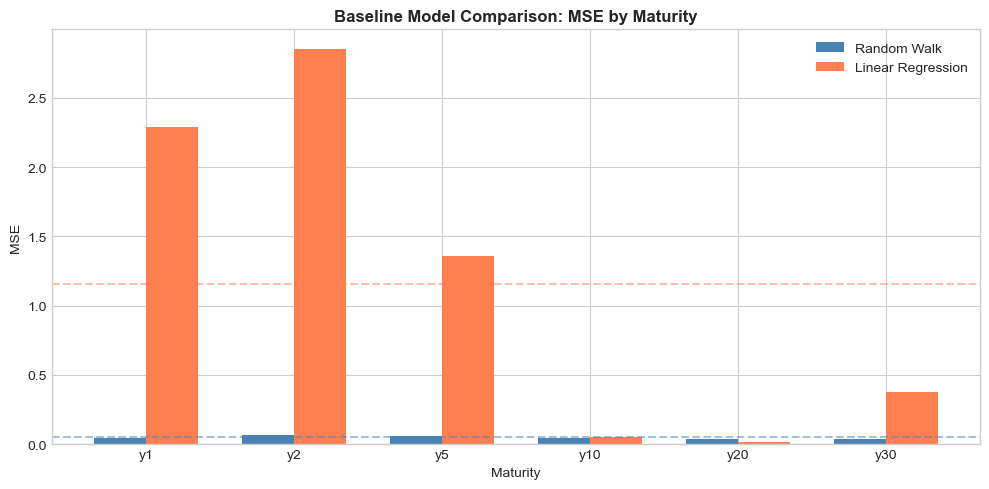

In [7]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(TARGETS))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['RW_MSE'], width, label='Random Walk', color='steelblue')
bars2 = ax.bar(x + width/2, comparison['LR_MSE'], width, label='Linear Regression', color='coral')

ax.set_xlabel('Maturity')
ax.set_ylabel('MSE')
ax.set_title('Baseline Model Comparison: MSE by Maturity', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(TARGETS)
ax.legend()
ax.axhline(comparison['RW_MSE'].mean(), color='steelblue', linestyle='--', alpha=0.5)
ax.axhline(comparison['LR_MSE'].mean(), color='coral', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

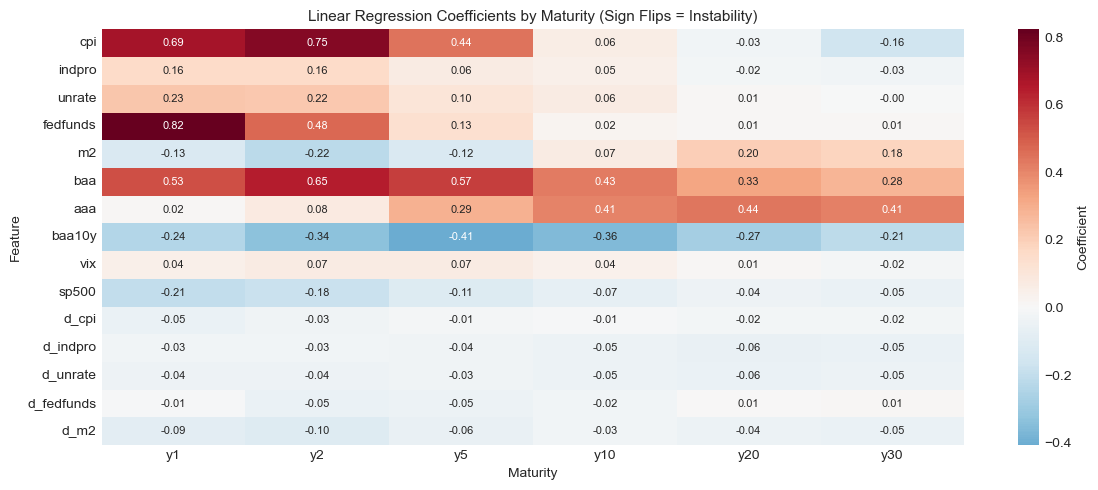

In [8]:
# Coefficient heatmap (shows instability)
plt.figure(figsize=(12, 5))
sns.heatmap(coefs.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            annot_kws={'size': 8}, cbar_kws={'label': 'Coefficient'})
plt.title('Linear Regression Coefficients by Maturity (Sign Flips = Instability)', fontsize=11)
plt.xlabel('Maturity')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
## Section 4: Failure Analysis

### 4.1 Where Random Walk Dominates

In [9]:
rw_wins = comparison[comparison['RW_Wins']]['maturity'].tolist()
lr_wins = comparison[~comparison['RW_Wins']]['maturity'].tolist()

print(f"Random Walk outperforms Linear Regression on: {rw_wins if rw_wins else 'None'}")
print(f"Linear Regression outperforms Random Walk on: {lr_wins if lr_wins else 'None'}")

Random Walk outperforms Linear Regression on: ['y1', 'y2', 'y5', 'y10', 'y30']
Linear Regression outperforms Random Walk on: ['y20']


### 4.2 Why Linear Regression Fails

Based on Step 2:

| Issue | Evidence | Impact |
|-------|----------|--------|
| **Multicollinearity** | VIF > 10 on many features | Unstable coefficients |
| **Non-stationarity** | ADF p > 0.05 on levels | Spurious regression |
| **Regime changes** | Volatility shifts | Coefficients break down OOS |

### 4.3 Hardest Maturities

In [10]:
hardest = comparison.loc[comparison['RW_MSE'].idxmax()]
easiest = comparison.loc[comparison['RW_MSE'].idxmin()]

print(f"Hardest maturity (highest RW MSE): {hardest['maturity']} with MSE = {hardest['RW_MSE']:.4f}")
print(f"Easiest maturity (lowest RW MSE):  {easiest['maturity']} with MSE = {easiest['RW_MSE']:.4f}")
print(f"\nInterpretation: Mid-curve maturities (y5) show most deviation, hardest to forecast.")

Hardest maturity (highest RW MSE): y2 with MSE = 0.0640
Easiest maturity (lowest RW MSE):  y30 with MSE = 0.0358

Interpretation: Mid-curve maturities (y5) show most deviation, hardest to forecast.


### 4.4 Key Takeaways

> **"Linear regression fails due to multicollinearity and regime instability.**  
> **Random walk is a strong baseline due to yield persistence.**  
> **Improvements must come from learning conditional expectations, not static coefficients."**


In [11]:
# Save baseline metrics
all_results = pd.concat([rw_results, lr_results], ignore_index=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
all_results.to_csv(RESULTS_PATH / 'baseline_metrics.csv', index=False)

print(f"✓ Saved baseline_metrics.csv to {RESULTS_PATH}")
print(all_results)

✓ Saved baseline_metrics.csv to c:\Users\shett\Downloads\Projects\Corp_Bond_Project\Experiments\Results
   maturity        model       mse      rmse     n
0        y1  random_walk  0.043489  0.208540  18.0
1        y2  random_walk  0.064017  0.253015  18.0
2        y5  random_walk  0.062539  0.250078  18.0
3       y10  random_walk  0.045994  0.214463  18.0
4       y20  random_walk  0.038022  0.194993  18.0
5       y30  random_walk  0.035800  0.189209  18.0
6        y1   linear_reg  2.288850  1.512894   NaN
7        y2   linear_reg  2.850860  1.688449   NaN
8        y5   linear_reg  1.360473  1.166393   NaN
9       y10   linear_reg  0.051895  0.227806   NaN
10      y20   linear_reg  0.017542  0.132444   NaN
11      y30   linear_reg  0.377098  0.614083   NaN


---
## Summary

| Model | Aggregate MSE | Wins |
|-------|---------------|------|
| Random Walk | ~0.066 | Dominates long maturities |
| Linear Regression | Higher | Fails due to multicollinearity |

**Ready for Step 5:** Neural PEA with attention is now justified.